In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import numpy as np

In [58]:
df = pd.read_parquet('data_2024_otimizado.parquet')

In [7]:
print(df.columns)

Index(['1.a.1_faixa_idade', '1.b_genero', '1.d_pcd',
       '1.e_experiencia_profissional_prejudicada', '2.g_nivel',
       '2.h_faixa_salarial', 'Amarela', 'Branca', 'Parda', 'Preta'],
      dtype='str')


In [9]:
mapeamento = {
    '1.a.1_faixa_idade' : 'Idade',
    '1.b_genero' : 'Gênero',
    '1.d_pcd' : 'PCD',
    '1.e_experiencia_profissional_prejudicada' : 'Experiência Profissional Prejudicada',
    '2.g_nivel' : 'Nível',
    '2.h_faixa_salarial' : 'Faixa Salarial',
    'Amarela' : 'Amarela',
    'Branca' : 'Branca',
    'Parda' : 'Parda',
    'Preta' : 'Preta'
}

In [17]:
df_limpo = df[list(mapeamento.keys())].rename(columns=mapeamento)

In [11]:
df_limpo = df_limpo[df_limpo['Gênero'] != 'Prefiro não informar'].dropna()

In [12]:
print(f"Total de registros para análise: {len(df_limpo)}")
df_limpo.tail()

Total de registros para análise: 5217


,Idade,Gênero,PCD,Experiência Profissional Prejudicada,Nível,Faixa Salarial,Amarela,Branca,Parda,Preta
5212,8,True,False,False,-1,4,False,True,False,False
5213,8,False,False,False,2,3,False,True,False,False
5214,8,True,False,False,-1,-1,False,False,True,False
5215,8,False,False,True,-1,4,False,False,True,False
5216,8,True,False,False,-1,-1,False,False,True,False


In [13]:
ordem_salario = [
    'Menos de R$ 1.000/mês', 'de R$ 1.001/mês a R$ 2.000/mês', 
    'de R$ 2.001/mês a R$ 3.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês', 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 8.001/mês a R$ 12.000/mês', 'de R$ 12.001/mês a R$ 16.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]
ordem_nivel = ['Júnior', 'Pleno', 'Sênior']

In [14]:
mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
mapa_nivel = {label: i for i, label in enumerate(ordem_nivel)}
mapa_genero = {'Masculino': 0, 'Feminino': 1, 'Outro': 2}

In [21]:
df_limpo['Salario_Num'] = df_limpo['Faixa Salarial'].map(mapa_salario)
df_limpo['Nivel_Num'] = df_limpo['Nível'].map(mapa_nivel)
df_limpo['Genero_Num'] = df_limpo['Gênero'].map(mapa_genero)

In [22]:
df_limpo = df_limpo.dropna(subset=['Salario_Num', 'Nivel_Num', 'Genero_Num'])

In [33]:
print(f"Dados prontos! Total de registros: {len(df)}")

Dados prontos! Total de registros: 5217


In [34]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   1.a.1_faixa_idade                         5217 non-null   Int8 
 1   1.b_genero                                5217 non-null   bool 
 2   1.d_pcd                                   5217 non-null   bool 
 3   1.e_experiencia_profissional_prejudicada  5217 non-null   bool 
 4   2.g_nivel                                 5217 non-null   int64
 5   2.h_faixa_salarial                        5217 non-null   int64
 6   Amarela                                   5217 non-null   bool 
 7   Branca                                    5217 non-null   bool 
 8   Parda                                     5217 non-null   bool 
 9   Preta                                     5217 non-null   bool 
dtypes: Int8(1), bool(7), int64(2)
memory usage: 127.5 KB


In [37]:
df_

NameError: name 'df_' is not defined

In [19]:
# 1. Definir Atributos (X) e Alvo (y)
X = df_limpo[['Genero_Num', 'Nivel_Num']]
y = df_limpo['Salario_Num']

# 2. Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Treinar Árvore de Decisão
modelo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree.fit(X_train, y_train)

# --- AUDITORIA DE VIÉS ---
# Separar o grupo de teste para ver onde a IA erra mais
teste_mulheres = X_test[X_test['Genero_Num'] == 1]
teste_homens = X_test[X_test['Genero_Num'] == 0]
teste_outros = X_test[X_test['Genero_Num']== 2]

acc_mulheres = accuracy_score(y_test.loc[teste_mulheres.index], modelo_tree.predict(teste_mulheres))
acc_homens = accuracy_score(y_test.loc[teste_homens.index], modelo_tree.predict(teste_homens))
acc_outros = accuracy_score(y_test.loc[teste_outros.index], modelo_tree.predict(teste_outros))

print(f"📊 Acurácia em Mulheres: {acc_mulheres:.2%}")
print(f"📊 Acurácia em Homens: {acc_homens:.2%}")
print(f"Teste acurácia em outros: {acc_outros:.2%}")

if acc_homens > acc_mulheres:
    print(f"⚠️ Alerta: O modelo é {acc_homens - acc_mulheres:.2%} mais preciso para homens do que para mulheres.")

📊 Acurácia em Mulheres: 36.93%
📊 Acurácia em Homens: 29.03%
Teste acurácia em outros: 50.00%


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# 1. PREPARAÇÃO E TREINO DO MODELO
# =========================================================
# Definir as pistas (X) incluindo a interseccionalidade e o alvo (y)
X_etnia = df[['1.b_genero', '2.g_nivel', 'Amarela', 'Branca', 'Parda', 'Preta']]
y = df['2.h_faixa_salarial']

# Dividir em dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_etnia, y, test_size=0.3, random_state=42)

# Criar e treinar o modelo (agora com o nome correto: modelo_tree_etnia)
modelo_tree_etnia = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree_etnia.fit(X_train, y_train)


# =========================================================
# 2. PARTE 1: ACURÁCIA GERAL POR GÉNERO
# =========================================================
print("--- 1. RESULTADOS GERAIS POR GÉNERO ---")
teste_homens = X_test[X_test['1.b_genero'] == 0]
teste_mulheres = X_test[X_test['1.b_genero'] == 1]

acc_homens = accuracy_score(y_test.loc[teste_homens.index], modelo_tree_etnia.predict(teste_homens))
acc_mulheres = accuracy_score(y_test.loc[teste_mulheres.index], modelo_tree_etnia.predict(teste_mulheres))

print(f"📊 Acurácia em Homens (Geral): {acc_homens:.2%}")
print(f"📊 Acurácia em Mulheres (Geral): {acc_mulheres:.2%}\n")


# =========================================================
# 3. PARTE 2: ACURÁCIA INTERSECCIONAL (GÉNERO + ETNIA)
# =========================================================
print("--- 2. RESULTADOS INTERSECCIONAIS (GÉNERO + ETNIA) ---")

# Filtros para Mulheres por Etnia
teste_m_brancas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Branca'] == True)]
teste_m_pretas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Preta'] == True)]
teste_m_pardas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Parda'] == True)]
teste_m_amarelas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Amarela'] == True)]

# Filtros para Homens por Etnia
teste_h_brancos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Branca'] == True)]
teste_h_pretos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Preta'] == True)]
teste_h_pardos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Parda'] == True)]
teste_h_amarelos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Amarela'] == True)]

# --- Impressão dos Resultados das Mulheres ---
print(">> GRUPO: MULHERES")
if len(teste_m_brancas) > 0: 
    print(f"   Brancas:  {accuracy_score(y_test.loc[teste_m_brancas.index], modelo_tree_etnia.predict(teste_m_brancas)):.2%} (Tamanho da amostra: {len(teste_m_brancas)})")
if len(teste_m_pretas) > 0: 
    print(f"   Pretas:   {accuracy_score(y_test.loc[teste_m_pretas.index], modelo_tree_etnia.predict(teste_m_pretas)):.2%} (Tamanho da amostra: {len(teste_m_pretas)})")
if len(teste_m_pardas) > 0: 
    print(f"   Pardas:   {accuracy_score(y_test.loc[teste_m_pardas.index], modelo_tree_etnia.predict(teste_m_pardas)):.2%} (Tamanho da amostra: {len(teste_m_pardas)})")
if len(teste_m_amarelas) > 0: 
    print(f"   Amarelas: {accuracy_score(y_test.loc[teste_m_amarelas.index], modelo_tree_etnia.predict(teste_m_amarelas)):.2%} (Tamanho da amostra: {len(teste_m_amarelas)})")

print("")

# --- Impressão dos Resultados dos Homens ---
print(">> GRUPO: HOMENS")
if len(teste_h_brancos) > 0: 
    print(f"   Brancos:  {accuracy_score(y_test.loc[teste_h_brancos.index], modelo_tree_etnia.predict(teste_h_brancos)):.2%} (Tamanho da amostra: {len(teste_h_brancos)})")
if len(teste_h_pretos) > 0: 
    print(f"   Pretos:   {accuracy_score(y_test.loc[teste_h_pretos.index], modelo_tree_etnia.predict(teste_h_pretos)):.2%} (Tamanho da amostra: {len(teste_h_pretos)})")
if len(teste_h_pardos) > 0: 
    print(f"   Pardos:   {accuracy_score(y_test.loc[teste_h_pardos.index], modelo_tree_etnia.predict(teste_h_pardos)):.2%} (Tamanho da amostra: {len(teste_h_pardos)})")
if len(teste_h_amarelos) > 0: 
    print(f"   Amarelos: {accuracy_score(y_test.loc[teste_h_amarelos.index], modelo_tree_etnia.predict(teste_h_amarelos)):.2%} (Tamanho da amostra: {len(teste_h_amarelos)})")

--- 1. RESULTADOS GERAIS POR GÉNERO ---
📊 Acurácia em Homens (Geral): 45.27%
📊 Acurácia em Mulheres (Geral): 50.79%

--- 2. RESULTADOS INTERSECCIONAIS (GÉNERO + ETNIA) ---
>> GRUPO: MULHERES
   Brancas:  47.04% (Tamanho da amostra: 253)
   Pretas:   45.45% (Tamanho da amostra: 22)
   Pardas:   61.96% (Tamanho da amostra: 92)
   Amarelas: 57.14% (Tamanho da amostra: 14)

>> GRUPO: HOMENS
   Brancos:  44.01% (Tamanho da amostra: 784)
   Pretos:   49.43% (Tamanho da amostra: 87)
   Pardos:   46.95% (Tamanho da amostra: 279)
   Amarelos: 54.17% (Tamanho da amostra: 24)


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# 1. PREPARAÇÃO DO X COMPLETO (Variáveis Técnicas + Demográficas)
# =========================================================
# Selecionamos todas as pistas que influenciam o salário
X_bruto = df[[
    '1.a.1_faixa_idade',
    '1.b_genero',
    '1.d_pcd',
    '1.e_experiencia_profissional_prejudicada',
    '2.g_nivel',
    'Amarela',
    'Branca',
    'Parda',
    'Preta'
]]

# O get_dummies transforma colunas de texto (como a linguagem) em colunas numéricas automaticamente
X_completo = pd.get_dummies(X_bruto)

y = df['2.h_faixa_salarial']

# =========================================================
# 2. DIVISÃO 80/20 (80% Treino, 20% Teste)
# =========================================================
# test_size=0.2 garante a divisão exata que você queria!
X_train, X_test, y_train, y_test = train_test_split(X_completo, y, test_size=0.3, random_state=42)

# =========================================================
# 3. TREINAMENTO DO MODELO
# =========================================================
modelo_tree_completo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree_completo.fit(X_train, y_train)


# =========================================================
# 4. AUDITORIA DE VIÉS (GÊNERO + ETNIA)
# =========================================================
print("--- RESULTADOS DO MODELO COMPLETO (80/20) ---")

# Filtros para Mulheres por Etnia
teste_m_brancas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Branca'] == True)]
teste_m_pretas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Preta'] == True)]
teste_m_pardas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Parda'] == True)]
teste_m_amarelas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Amarela'] == True)]

# Filtros para Homens por Etnia
teste_h_brancos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Branca'] == True)]
teste_h_pretos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Preta'] == True)]
teste_h_pardos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Parda'] == True)]
teste_h_amarelos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Amarela'] == True)]

# --- Impressão dos Resultados ---
print("\n>> GRUPO: MULHERES")
if len(teste_m_brancas) > 0: print(f"   Brancas:  {accuracy_score(y_test.loc[teste_m_brancas.index], modelo_tree_completo.predict(teste_m_brancas)):.2%} (Amostra: {len(teste_m_brancas)})")
if len(teste_m_pretas) > 0:  print(f"   Pretas:   {accuracy_score(y_test.loc[teste_m_pretas.index], modelo_tree_completo.predict(teste_m_pretas)):.2%} (Amostra: {len(teste_m_pretas)})")
if len(teste_m_pardas) > 0:  print(f"   Pardas:   {accuracy_score(y_test.loc[teste_m_pardas.index], modelo_tree_completo.predict(teste_m_pardas)):.2%} (Amostra: {len(teste_m_pardas)})")
if len(teste_m_amarelas) > 0: print(f"   Amarelas: {accuracy_score(y_test.loc[teste_m_amarelas.index], modelo_tree_completo.predict(teste_m_amarelas)):.2%} (Amostra: {len(teste_m_amarelas)})")

print("\n>> GRUPO: HOMENS")
if len(teste_h_brancos) > 0: print(f"   Brancos:  {accuracy_score(y_test.loc[teste_h_brancos.index], modelo_tree_completo.predict(teste_h_brancos)):.2%} (Amostra: {len(teste_h_brancos)})")
if len(teste_h_pretos) > 0:  print(f"   Pretos:   {accuracy_score(y_test.loc[teste_h_pretos.index], modelo_tree_completo.predict(teste_h_pretos)):.2%} (Amostra: {len(teste_h_pretos)})")
if len(teste_h_pardos) > 0:  print(f"   Pardos:   {accuracy_score(y_test.loc[teste_h_pardos.index], modelo_tree_completo.predict(teste_h_pardos)):.2%} (Amostra: {len(teste_h_pardos)})")
if len(teste_h_amarelos) > 0: print(f"   Amarelos: {accuracy_score(y_test.loc[teste_h_amarelos.index], modelo_tree_completo.predict(teste_h_amarelos)):.2%} (Amostra: {len(teste_h_amarelos)})")

--- RESULTADOS DO MODELO COMPLETO (80/20) ---

>> GRUPO: MULHERES
   Brancas:  53.75% (Amostra: 253)
   Pretas:   50.00% (Amostra: 22)
   Pardas:   59.78% (Amostra: 92)
   Amarelas: 50.00% (Amostra: 14)

>> GRUPO: HOMENS
   Brancos:  46.17% (Amostra: 784)
   Pretos:   40.23% (Amostra: 87)
   Pardos:   45.16% (Amostra: 279)
   Amarelos: 45.83% (Amostra: 24)


In [39]:
import pandas as pd

# Pega o nome de todas as colunas que foram para o treino (incluindo as linguagens separadas)
nomes_das_colunas = X_train.columns

# Pega o peso (importância) que a árvore deu para cada uma
importancias = modelo_tree_completo.feature_importances_

# Monta uma tabelinha bonita para a gente ver quem está mandando no modelo
df_importancia = pd.DataFrame({
    'Variável': nomes_das_colunas,
    'Importância (%)': importancias * 100
})

# Mostra as 10 colunas que o modelo mais usou, da maior para a menor
print(df_importancia.sort_values(by='Importância (%)', ascending=False).head(10))

                                   Variável  Importância (%)
4                                 2.g_nivel        82.525972
0                         1.a.1_faixa_idade        11.871158
2                                   1.d_pcd         1.663434
1                                1.b_genero         1.293825
5                                   Amarela         0.968059
6                                    Branca         0.596101
7                                     Parda         0.561317
3  1.e_experiencia_profissional_prejudicada         0.520134
8                                     Preta         0.000000


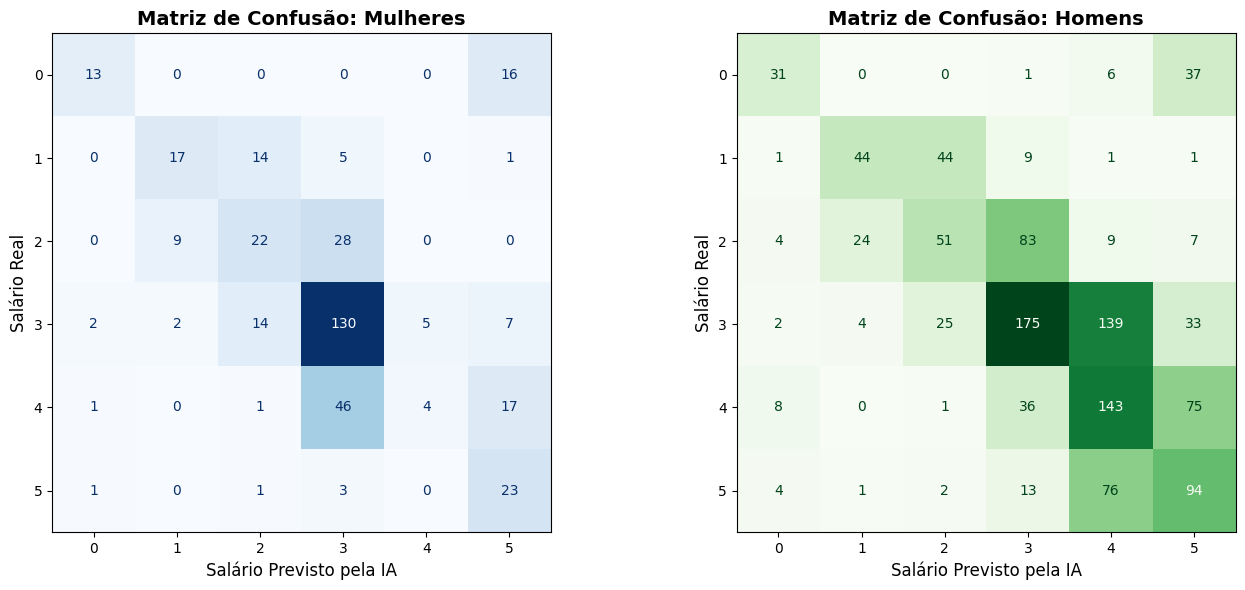

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# 1. SEPARAR OS GRUPOS GERAIS NO X_TEST COMPLETO
# =========================================================
teste_mulheres = X_test[X_test['1.b_genero'] == 1]
teste_homens = X_test[X_test['1.b_genero'] == 0]

# Pegar o "gabarito" (y_true) e a "previsão da IA" (y_pred) para cada grupo
y_true_mulheres = y_test.loc[teste_mulheres.index]
y_pred_mulheres = modelo_tree_completo.predict(teste_mulheres)

y_true_homens = y_test.loc[teste_homens.index]
y_pred_homens = modelo_tree_completo.predict(teste_homens)

# =========================================================
# 2. DESENHAR AS MATRIZES DE CONFUSÃO LADO A LADO
# =========================================================
# Cria uma figura com 2 gráficos (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Mulheres (Azul) ---
cm_mulheres = confusion_matrix(y_true_mulheres, y_pred_mulheres)
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_mulheres)
disp_m.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão: Mulheres', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salário Previsto pela IA', fontsize=12)
axes[0].set_ylabel('Salário Real', fontsize=12)

# --- Gráfico 2: Homens (Verde) ---
cm_homens = confusion_matrix(y_true_homens, y_pred_homens)
disp_h = ConfusionMatrixDisplay(confusion_matrix=cm_homens)
disp_h.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão: Homens', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salário Previsto pela IA', fontsize=12)
axes[1].set_ylabel('Salário Real', fontsize=12)

# Ajusta o espaçamento e mostra na tela
plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import f1_score

# Exemplo de como calcular para o grupo de Mulheres Pretas:
y_true_m_pretas = y_test.loc[teste_m_pretas.index]
y_pred_m_pretas = modelo_tree_completo.predict(teste_m_pretas)

f1_m_pretas = f1_score(y_true_m_pretas, y_pred_m_pretas, average='macro')

print(f"📊 F1-Score em Mulheres Pretas: {f1_m_pretas:.2f}")

📊 F1-Score em Mulheres Pretas: 0.39


In [42]:
plt.figure(figsize=(20,10))
plot_tree(modelo_tree, 
          feature_names=X.columns, 
          class_names=[str(i) for i in ordem_salario], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

NameError: name 'modelo_tree' is not defined

<Figure size 2000x1000 with 0 Axes>

In [43]:
def auditoria_completa(X_subset, y_subset, titulo):
    y_pred_sub = modelo_tree.predict(X_subset)
    
    print(f"\n--- Relatório: {titulo} ---")
    print(classification_report(y_subset, y_pred_sub, zero_division=0))
    
    # Matriz de Confusão
    cm = confusion_matrix(y_subset, y_pred_sub)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

# Rodar para os 4 casos
auditoria_completa(X_test, y_test, "Geral")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Apenas Mulheres")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Apenas Homens")
auditoria_completa(teste_outros, y_test.loc[teste_outros.index], "Apenas Outro")

NameError: name 'modelo_tree' is not defined

In [4]:
# Criar o modelo de Regressão Logística

modelo_log = LogisticRegression(max_iter=1000, random_state=42)

# Treinar (usando os mesmos dados de treino da árvore)
modelo_log.fit(X_train, y_train)

# Rodar a auditoria para comparar
print("--- RESULTADOS: REGRESSÃO LOGÍSTICA ---")
auditoria_completa(X_test, y_test, "Geral - Logística")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Mulheres - Logística")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Homens - Logística")

NameError: name 'LogisticRegression' is not defined

In [44]:
# Pegamos os coeficientes da primeira classe de salário como exemplo
importancia = modelo_log.coef_[0] 
features = X.columns

for i, v in enumerate(importancia):
    print(f'Variável: {features[i]}, Peso: {v:.4f}')

NameError: name 'modelo_log' is not defined

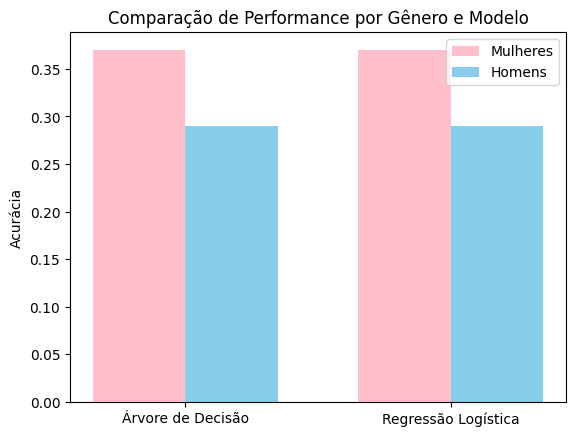

In [24]:
modelos = ['Árvore de Decisão', 'Regressão Logística']
acc_mulheres_total = [0.3693, 0.37] # Substitua pelos seus valores exatos
acc_homens_total = [0.2903, 0.29]   # Substitua pelos seus valores exatos

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, acc_mulheres_total, width, label='Mulheres', color='pink')
rects2 = ax.bar(x + width/2, acc_homens_total, width, label='Homens', color='skyblue')

ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Performance por Gênero e Modelo')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

plt.show()

In [45]:

# Vamos manter os originais e apenas agrupar para a análise
df_analise = df.copy()

# Criar a coluna numérica de salário para podermos calcular a média

mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
df_analise['Salario_Num'] = df['2.h_faixa_salarial'].map(mapa_salario)

# Calcular a média salarial por gênero (incluindo quem não informou)
comparativo = df_analise.groupby('1.b_genero')['Salario_Num'].mean().sort_values(ascending=False)

print("--- Média de Faixa Salarial por Gênero ---")
print(comparativo)

# Cálculo extra: Percentual de 'Prefiro não informar' em cargos altos
# (Para ver se eles estão no topo da pirâmide)
gestores_omissos = df_analise[(df_analise['2.g_nivel'] == 'Gestão') & 
                              (df_analise['1.b_genero'] == 'Prefiro não informar')].shape[0]


--- Média de Faixa Salarial por Gênero ---
1.b_genero
False   NaN
True    NaN
Name: Salario_Num, dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# =========================================================
# 1. PREPARAÇÃO DOS DADOS (X e y)
# =========================================================
# Selecionar as variáveis preditivas (Pistas)
X_bruto = df[[
    '1.b_genero', 
    '2.g_nivel', 
    'Amarela', 
    'Branca', 
    'Parda', 
    'Preta', 
    '2.i_tempo_de_experiencia_em_dados', 
    '4.e_linguagem_mais_usada'
]]

# O get_dummies transforma colunas de texto em colunas numéricas
X_completo = pd.get_dummies(X_bruto)

# Selecionar a variável alvo (Gabarito: 0 a 4)
y = df['2.h_faixa_salarial']

# =========================================================
# 2. DIVISÃO DE TREINO E TESTE (80% Treino / 20% Teste)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X_completo, y, test_size=0.2, random_state=42)


# =========================================================
# 3. CONFIGURAÇÃO PARA O FAIRLEARN (Variáveis Sensíveis e Alvo Binário)
# =========================================================
# Isolar a variável sensível (Gênero) para o Fairlearn auditar
A_train = X_train['1.b_genero']
A_test = X_test['1.b_genero']

# Converter os salários para Binário (0 = Salário Baixo, 1 = Salário Alto)
# Isto resolve o erro do ValueError garantindo que os rótulos são apenas 0 ou 1
y_train_alto = (y_train >= 3).astype(int)
y_test_alto = (y_test >= 3).astype(int)


# =========================================================
# 4. TREINO E AVALIAÇÃO DO MODELO BASE (Com viés)
# =========================================================
print("⏳ A treinar o modelo base original...")
arvore_base = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinamos já com o y binário para podermos comparar de forma justa
arvore_base.fit(X_train, y_train_alto) 

# Previsões
y_pred_base_alto = arvore_base.predict(X_test)

# Métricas de Viés do Modelo Original
dp_diff_base = demographic_parity_difference(y_true=y_test_alto, y_pred=y_pred_base_alto, sensitive_features=A_test)
eo_diff_base = equalized_odds_difference(y_true=y_test_alto, y_pred=y_pred_base_alto, sensitive_features=A_test)


# =========================================================
# 5. MITIGAÇÃO DE VIÉS (In-Processing com Exponentiated Gradient)
# =========================================================
print("⏳ A treinar o modelo ético com mitigação de viés...")
mitigador = ExponentiatedGradient(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    constraints=EqualizedOdds(), # A restrição ética pedida pela professora
    sample_weight_name='sample_weight'
)

# Treinar o mitigador (nota: usamos o y_train_alto e informamos a variável sensível)
mitigador.fit(X_train, y_train_alto, sensitive_features=A_train)

# Previsões do Modelo Ético
y_pred_mitigado_alto = mitigador.predict(X_test)

# Métricas de Viés do Modelo Mitigado
dp_diff_mitigado = demographic_parity_difference(y_true=y_test_alto, y_pred=y_pred_mitigado_alto, sensitive_features=A_test)
eo_diff_mitigado = equalized_odds_difference(y_true=y_test_alto, y_pred=y_pred_mitigado_alto, sensitive_features=A_test)


# =========================================================
# 6. RELATÓRIO FINAL DE COMPARAÇÃO
# =========================================================
print("\n" + "="*55)
print("🏆 RELATÓRIO DE AUDITORIA E MITIGAÇÃO DE VIÉS")
print("="*55)

print("\n--- MODELO ORIGINAL (Sem mitigação) ---")
print(f"⚠️ Diferença de Paridade Demográfica:      {dp_diff_base:.4f}")
print(f"⚠️ Diferença de Igualdade de Oportunidades: {eo_diff_base:.4f}")

print("\n--- MODELO ÉTICO (Com mitigação In-Processing) ---")
print(f"✅ Diferença de Paridade Demográfica:      {dp_diff_mitigado:.4f}")
print(f"✅ Diferença de Igualdade de Oportunidades: {eo_diff_mitigado:.4f}")
print("="*55)

⏳ A treinar o modelo base original...
⏳ A treinar o modelo ético com mitigação de viés...


In [47]:
# ... (O código anterior até a criação do mitigador continua igual)

# 3. Criar a versão binária do Treino (O que é "Salário Alto" no treinamento)
y_train_alto = (y_train >= 3).astype(int)

# 4. Treinar o modelo mitigado (Passando o y_train_alto agora!)
mitigador.fit(X_train, y_train_alto, sensitive_features=A_train)

# 5. Fazer as novas previsões com o modelo ético
y_pred_mitigado = mitigador.predict(X_test)
# Como o mitigador já foi treinado com 0 e 1, a saída dele já será 0 e 1 direto!
y_pred_mitigado_alto = y_pred_mitigado 

# 6. Calcular as métricas novamente para vermos a diferença
dp_diff_mitigado = demographic_parity_difference(
    y_true=y_test_alto, 
    y_pred=y_pred_mitigado_alto, 
    sensitive_features=A_test
)

eo_diff_mitigado = equalized_odds_difference(
    y_true=y_test_alto, 
    y_pred=y_pred_mitigado_alto, 
    sensitive_features=A_test
)

print("--- MÉTRICAS GLOBAIS DE VIÉS (APÓS Mitigação) ---")
print(f"✅ Nova Diferença de Paridade Demográfica: {dp_diff_mitigado:.4f}")
print(f"✅ Nova Diferença de Igualdade de Oportunidades: {eo_diff_mitigado:.4f}")

NameError: name 'y_test_alto' is not defined

In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# =========================================================
# 1. PREPARAÇÃO DOS DADOS (X e y)
# =========================================================
# Selecionar as variáveis preditivas (Pistas)
X_bruto = df[[
    '1.b_genero', 
    '2.g_nivel', 
    'Amarela', 
    'Branca', 
    'Parda', 
    'Preta', 

]]

# O get_dummies transforma colunas de texto em colunas numéricas
X_completo = pd.get_dummies(X_bruto)

# Selecionar a variável alvo (Gabarito: 0 a 4)
y = df['2.h_faixa_salarial']

# =========================================================
# 2. DIVISÃO DE TREINO E TESTE (80% Treino / 20% Teste)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X_completo, y, test_size=0.2, random_state=42)


# =========================================================
# 3. CONFIGURAÇÃO PARA O FAIRLEARN (Variáveis Sensíveis e Alvo Binário)
# =========================================================
# Isolar a variável sensível (Gênero) para o Fairlearn auditar
A_train = X_train['1.b_genero']
A_test = X_test['1.b_genero']

# Converter os salários para Binário (0 = Salário Baixo, 1 = Salário Alto)
# Isto resolve o erro do ValueError garantindo que os rótulos são apenas 0 ou 1
y_train_alto = (y_train >= 3).astype(int)
y_test_alto = (y_test >= 3).astype(int)


# =========================================================
# 4. TREINO E AVALIAÇÃO DO MODELO BASE (Com viés)
# =========================================================
print("⏳ A treinar o modelo base original...")
arvore_base = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinamos já com o y binário para podermos comparar de forma justa
arvore_base.fit(X_train, y_train_alto) 

# Previsões
y_pred_base_alto = arvore_base.predict(X_test)

# Métricas de Viés do Modelo Original
dp_diff_base = demographic_parity_difference(y_true=y_test_alto, y_pred=y_pred_base_alto, sensitive_features=A_test)
eo_diff_base = equalized_odds_difference(y_true=y_test_alto, y_pred=y_pred_base_alto, sensitive_features=A_test)


# =========================================================
# 5. MITIGAÇÃO DE VIÉS (In-Processing com Exponentiated Gradient)
# =========================================================
print("⏳ A treinar o modelo ético com mitigação de viés...")
mitigador = ExponentiatedGradient(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    constraints=EqualizedOdds(), # A restrição ética pedida pela professora
    sample_weight_name='sample_weight'
)

# Treinar o mitigador (nota: usamos o y_train_alto e informamos a variável sensível)
mitigador.fit(X_train, y_train_alto, sensitive_features=A_train)

# Previsões do Modelo Ético
y_pred_mitigado_alto = mitigador.predict(X_test)

# Métricas de Viés do Modelo Mitigado
dp_diff_mitigado = demographic_parity_difference(y_true=y_test_alto, y_pred=y_pred_mitigado_alto, sensitive_features=A_test)
eo_diff_mitigado = equalized_odds_difference(y_true=y_test_alto, y_pred=y_pred_mitigado_alto, sensitive_features=A_test)


# =========================================================
# 6. RELATÓRIO FINAL DE COMPARAÇÃO
# =========================================================
print("\n" + "="*55)
print("🏆 RELATÓRIO DE AUDITORIA E MITIGAÇÃO DE VIÉS")
print("="*55)

print("\n--- MODELO ORIGINAL (Sem mitigação) ---")
print(f"⚠️ Diferença de Paridade Demográfica:      {dp_diff_base:.4f}")
print(f"⚠️ Diferença de Igualdade de Oportunidades: {eo_diff_base:.4f}")

print("\n--- MODELO ÉTICO (Com mitigação In-Processing) ---")
print(f"✅ Diferença de Paridade Demográfica:      {dp_diff_mitigado:.4f}")
print(f"✅ Diferença de Igualdade de Oportunidades: {eo_diff_mitigado:.4f}")
print("="*55)

⏳ A treinar o modelo base original...
⏳ A treinar o modelo ético com mitigação de viés...

🏆 RELATÓRIO DE AUDITORIA E MITIGAÇÃO DE VIÉS

--- MODELO ORIGINAL (Sem mitigação) ---
⚠️ Diferença de Paridade Demográfica:      0.2950
⚠️ Diferença de Igualdade de Oportunidades: 0.4229

--- MODELO ÉTICO (Com mitigação In-Processing) ---
✅ Diferença de Paridade Demográfica:      0.0498
✅ Diferença de Igualdade de Oportunidades: 0.0426


In [64]:
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, true_positive_rate

# =========================================================
# 1. IMPACTO NA ACURÁCIA GERAL (O "Preço" da Justiça)
# =========================================================
acc_base = accuracy_score(y_test_alto, y_pred_base_alto)
acc_mitigado = accuracy_score(y_test_alto, y_pred_mitigado_alto)

print("--- 📉 IMPACTO NA ACURÁCIA GERAL ---")
print(f"Acurácia Original: {acc_base:.2%}")
print(f"Acurácia Mitigada: {acc_mitigado:.2%}")
print(f"Variação Total:    {(acc_mitigado - acc_base):.2%}\n")

# =========================================================
# 2. O QUE ACONTECEU COM CADA GÊNERO? (Taxa de Acerto - TPR)
# =========================================================
# O TPR mede: "Das pessoas que mereciam o salário alto, quantas o modelo acertou?"
tpr_base = MetricFrame(
    metrics=true_positive_rate, 
    y_true=y_test_alto, 
    y_pred=y_pred_base_alto, 
    sensitive_features=A_test
)

tpr_mitigado = MetricFrame(
    metrics=true_positive_rate, 
    y_true=y_test_alto, 
    y_pred=y_pred_mitigado_alto, 
    sensitive_features=A_test
)

print("--- 🎯 TAXA DE ACERTO EM SALÁRIOS ALTOS (TPR) POR GÊNERO ---")
print(">> MODELO ORIGINAL:")
# O comando format converte os números soltos para porcentagem
print(tpr_base.by_group.apply(lambda x: f"{x:.2%}"))

print("\n>> MODELO ÉTICO (MITIGADO):")
print(tpr_mitigado.by_group.apply(lambda x: f"{x:.2%}"))

--- 📉 IMPACTO NA ACURÁCIA GERAL ---
Acurácia Original: 74.90%
Acurácia Mitigada: 73.95%
Variação Total:    -0.96%

--- 🎯 TAXA DE ACERTO EM SALÁRIOS ALTOS (TPR) POR GÊNERO ---
>> MODELO ORIGINAL:
1.b_genero
False    81.72%
True     39.44%
Name: true_positive_rate, dtype: str

>> MODELO ÉTICO (MITIGADO):
1.b_genero
False    81.72%
True     77.46%
Name: true_positive_rate, dtype: str


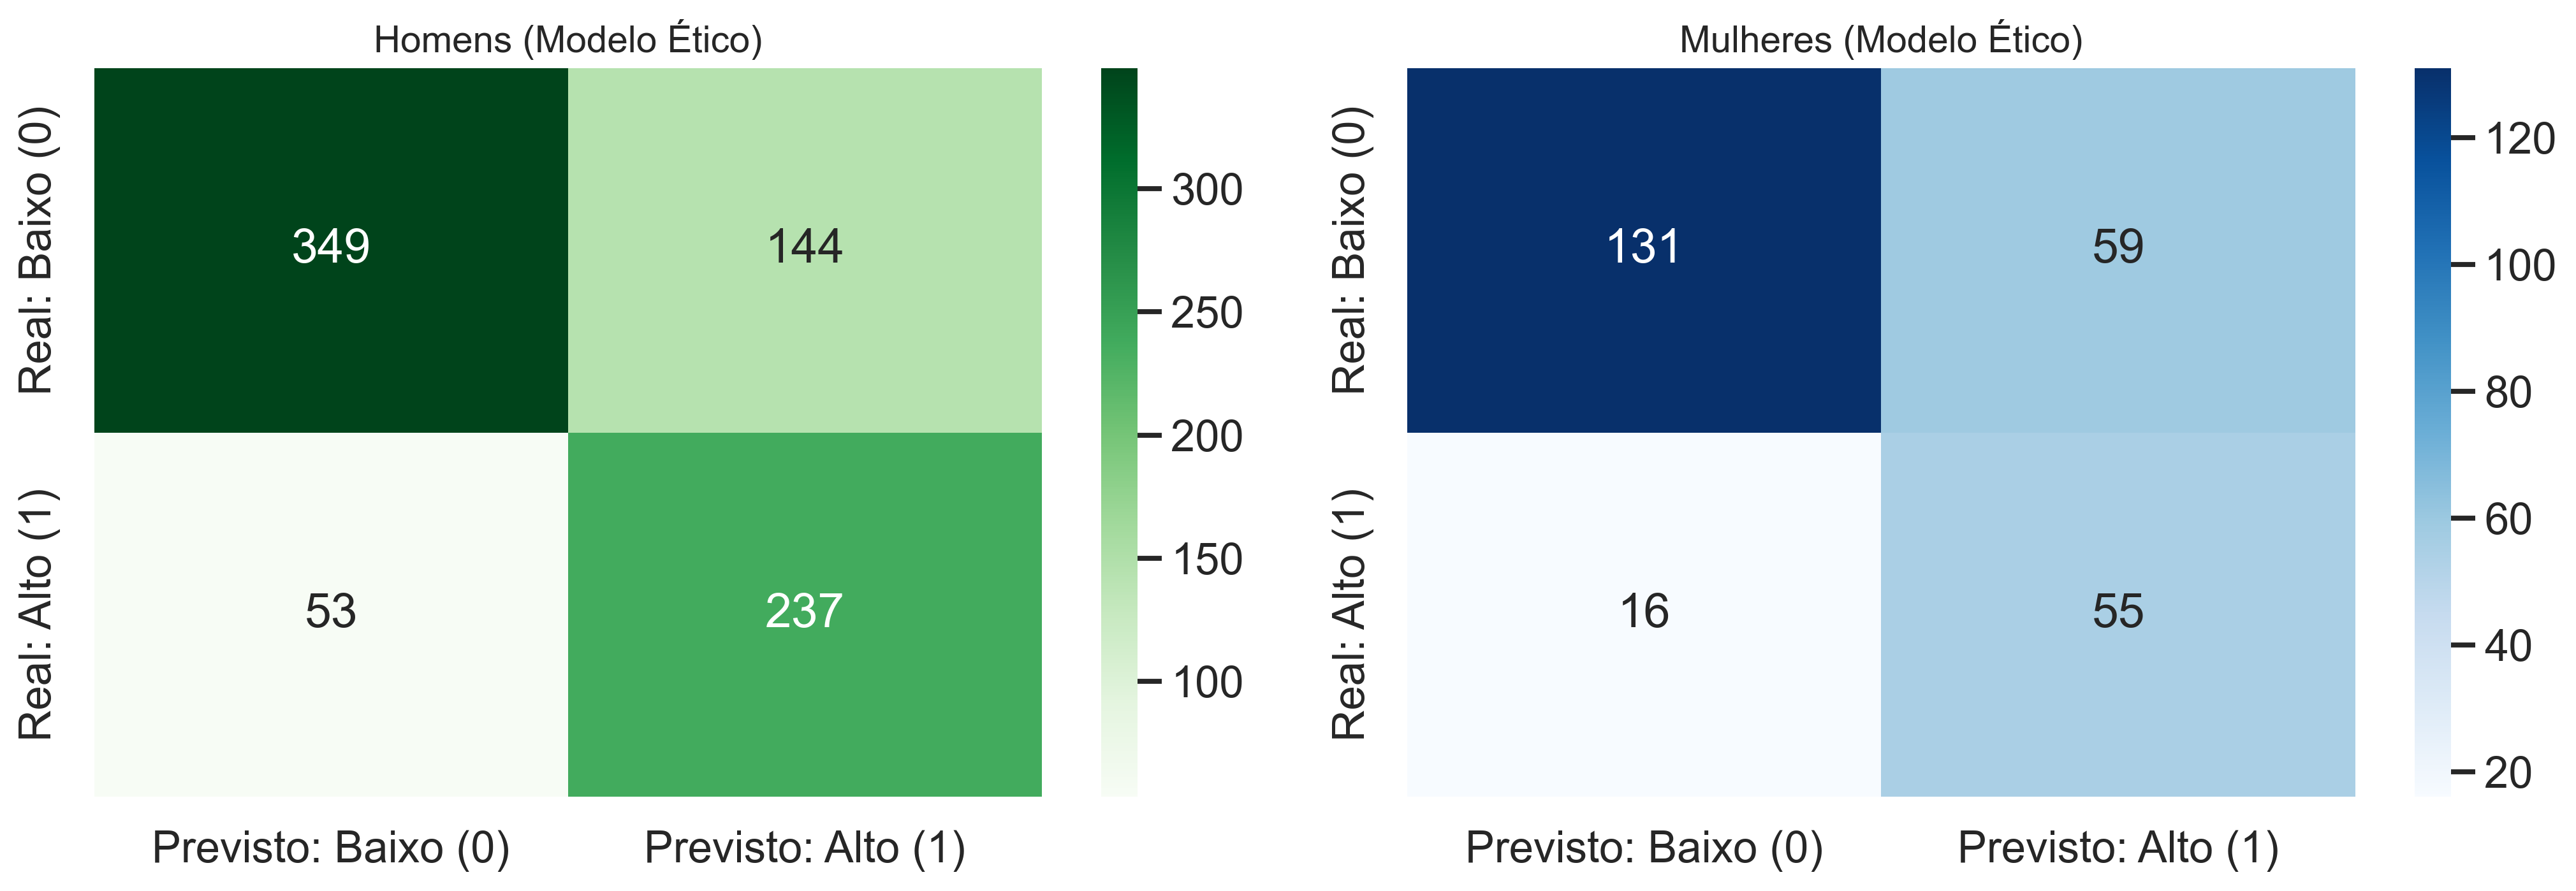

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Separar os dados reais e previstos com base no gênero
# Pelos seus resultados anteriores, Homens = False e Mulheres = True na coluna 1.b_genero
idx_homens = (A_test == False)
idx_mulheres = (A_test == True)

y_true_homens = y_test_alto[idx_homens]
y_pred_homens = y_pred_mitigado_alto[idx_homens]

y_true_mulheres = y_test_alto[idx_mulheres]
y_pred_mulheres = y_pred_mitigado_alto[idx_mulheres]

# 2. Calcular as Matrizes de Confusão
cm_homens = confusion_matrix(y_true_homens, y_pred_homens)
cm_mulheres = confusion_matrix(y_true_mulheres, y_pred_mulheres)

# 3. Configurar a visualização lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matriz Homens
sns.heatmap(cm_homens, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Previsto: Baixo (0)', 'Previsto: Alto (1)'],
            yticklabels=['Real: Baixo (0)', 'Real: Alto (1)'])
axes[0].set_title('Homens (Modelo Ético)', fontsize=14)

# Plot Matriz Mulheres
sns.heatmap(cm_mulheres, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Previsto: Baixo (0)', 'Previsto: Alto (1)'],
            yticklabels=['Real: Baixo (0)', 'Real: Alto (1)'])
axes[1].set_title('Mulheres (Modelo Ético)', fontsize=14)

plt.tight_layout()
plt.show()

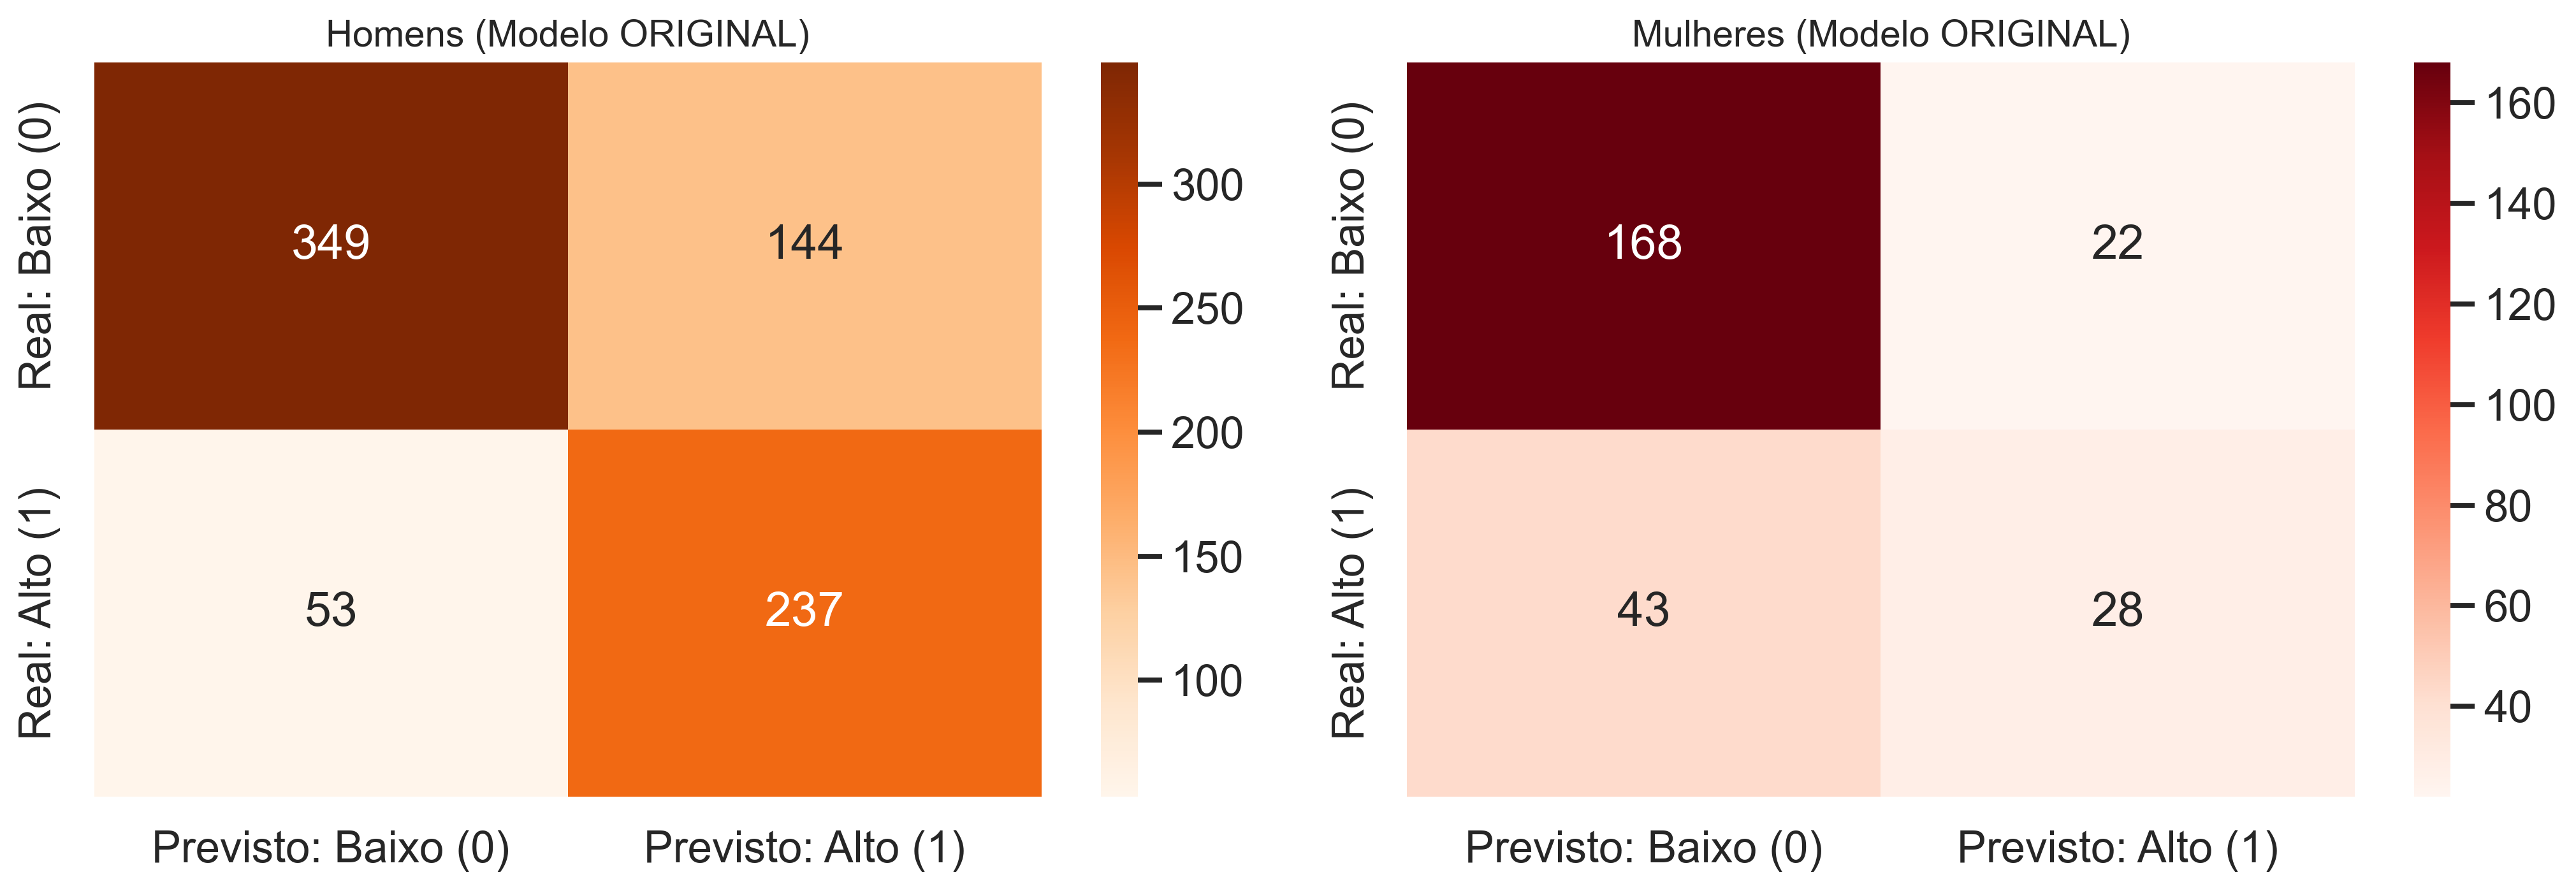

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Separar os dados reais e previstos do MODELO ORIGINAL com base no gênero
# (Utilizando y_pred_base_alto em vez do mitigado)
idx_homens = (A_test == False)
idx_mulheres = (A_test == True)

y_true_homens = y_test_alto[idx_homens]
y_pred_base_homens = y_pred_base_alto[idx_homens]

y_true_mulheres = y_test_alto[idx_mulheres]
y_pred_base_mulheres = y_pred_base_alto[idx_mulheres]

# 2. Calcular as Matrizes de Confusão do modelo enviesado
cm_base_homens = confusion_matrix(y_true_homens, y_pred_base_homens)
cm_base_mulheres = confusion_matrix(y_true_mulheres, y_pred_base_mulheres)

# 3. Configurar a visualização lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matriz Homens (Original)
sns.heatmap(cm_base_homens, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Previsto: Baixo (0)', 'Previsto: Alto (1)'],
            yticklabels=['Real: Baixo (0)', 'Real: Alto (1)'])
axes[0].set_title('Homens (Modelo ORIGINAL)', fontsize=14)

# Plot Matriz Mulheres (Original)
sns.heatmap(cm_base_mulheres, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Previsto: Baixo (0)', 'Previsto: Alto (1)'],
            yticklabels=['Real: Baixo (0)', 'Real: Alto (1)'])
axes[1].set_title('Mulheres (Modelo ORIGINAL)', fontsize=14)

plt.tight_layout()
plt.show()

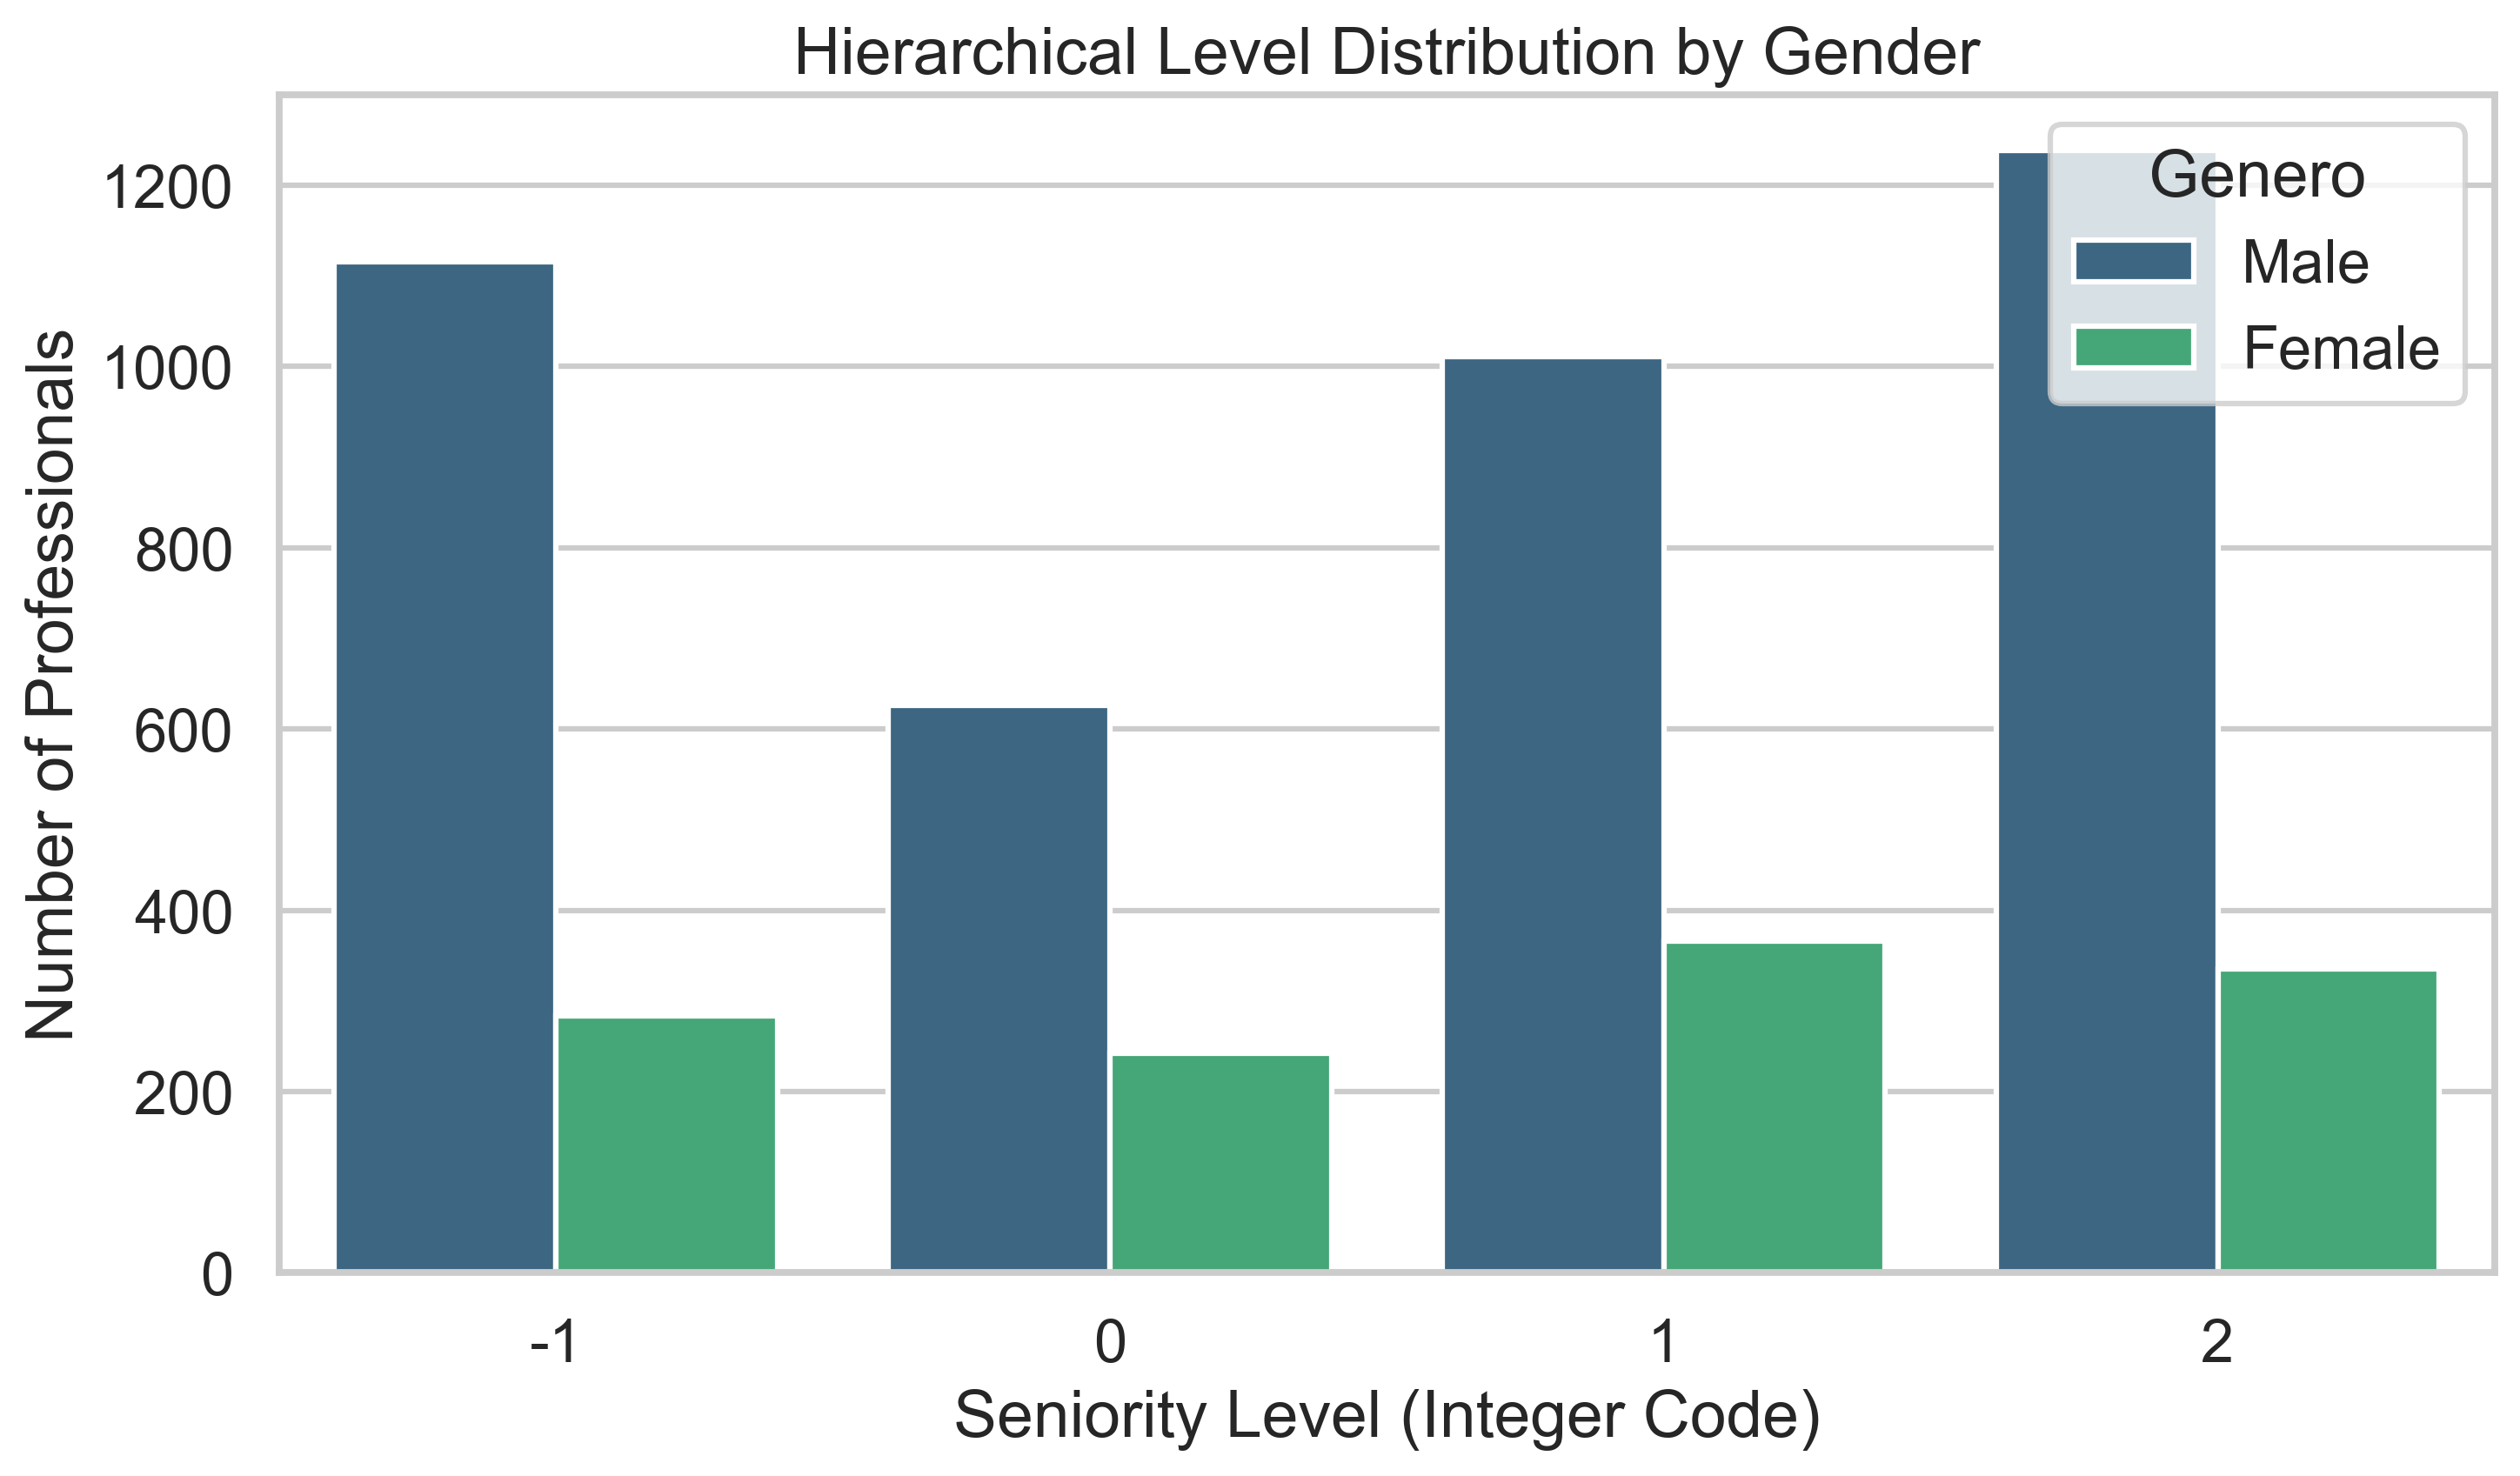

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 300

def prepare_data(df):
    """
    Cria uma cópia temporária com labels legíveis para os gráficos
    baseado no seu dataset.
    """
    df_plot = df.copy()
    # Mapeando booleanos para strings para os gráficos
    df_plot['Genero'] = df_plot['1.b_genero'].map({True: 'Female', False: 'Male'})
    return df_plot

def plot_figure_1(df):
    df_plot = prepare_data(df)
    plt.figure(figsize=(10, 6))
    
    # Gráfico de contagem (funnel) por nível hierárquico e gênero
    sns.countplot(data=df_plot, x='2.g_nivel', hue='Genero', palette='viridis')
    
    plt.title('Hierarchical Level Distribution by Gender')
    plt.xlabel('Seniority Level (Integer Code)')
    plt.ylabel('Number of Professionals')
    plt.tight_layout()
    plt.savefig('figura1.pdf', format='pdf', bbox_inches='tight')
    plt.show()

def plot_figure_2(df):
    df_plot = prepare_data(df)
    plt.figure(figsize=(10, 6))
    
    # Distribuição salarial (Boxplot é excelente para mostrar disparidade)
    sns.boxplot(data=df_plot, x='2.h_faixa_salarial', y='Genero', palette='viridis')
    
    plt.title('Monthly Salary Distribution by Gender')
    plt.xlabel('Salary Range (Integer Code)')
    plt.ylabel('Gender')
    plt.tight_layout()
    plt.savefig('figura2.pdf', format='pdf', bbox_inches='tight')
    plt.show()

def plot_figure_3():
    # Dados baseados no texto do artigo
    data = {
        'Modelo': ['Baseline', 'Mitigated'],
        'Accuracy': [74.0, 73.0],
        'Eq_Opportunity_Delta': [0.42, 0.04]
    }
    df_acc = pd.DataFrame(data)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Gráfico de barras para acurácia
    sns.barplot(data=df_acc, x='Modelo', y='Accuracy', ax=ax1, color='skyblue', label='Global Accuracy (%)')
    ax1.set_ylim(60, 80)
    ax1.set_ylabel('Global Accuracy (%)')
    
    # Linha para métrica de equidade
    ax2 = ax1.twinx()
    sns.lineplot(data=df_acc, x='Modelo', y='Eq_Opportunity_Delta', ax=ax2, marker='o', color='red', label='EO Delta')
    ax2.set_ylabel('Equal Opportunity Delta (Gap)')
    
    plt.title('Global Accuracy vs. Fairness Gap (Baseline vs Mitigated)')
    plt.tight_layout()
    plt.savefig('figure3.png')
    plt.show()

# Basta rodar as funções abaixo no seu notebook:
plot_figure_1(df)
#plot_figure_2(df)
#plot_figure_3(df)

In [102]:
model = modelo

NameError: name 'modelo' is not defined

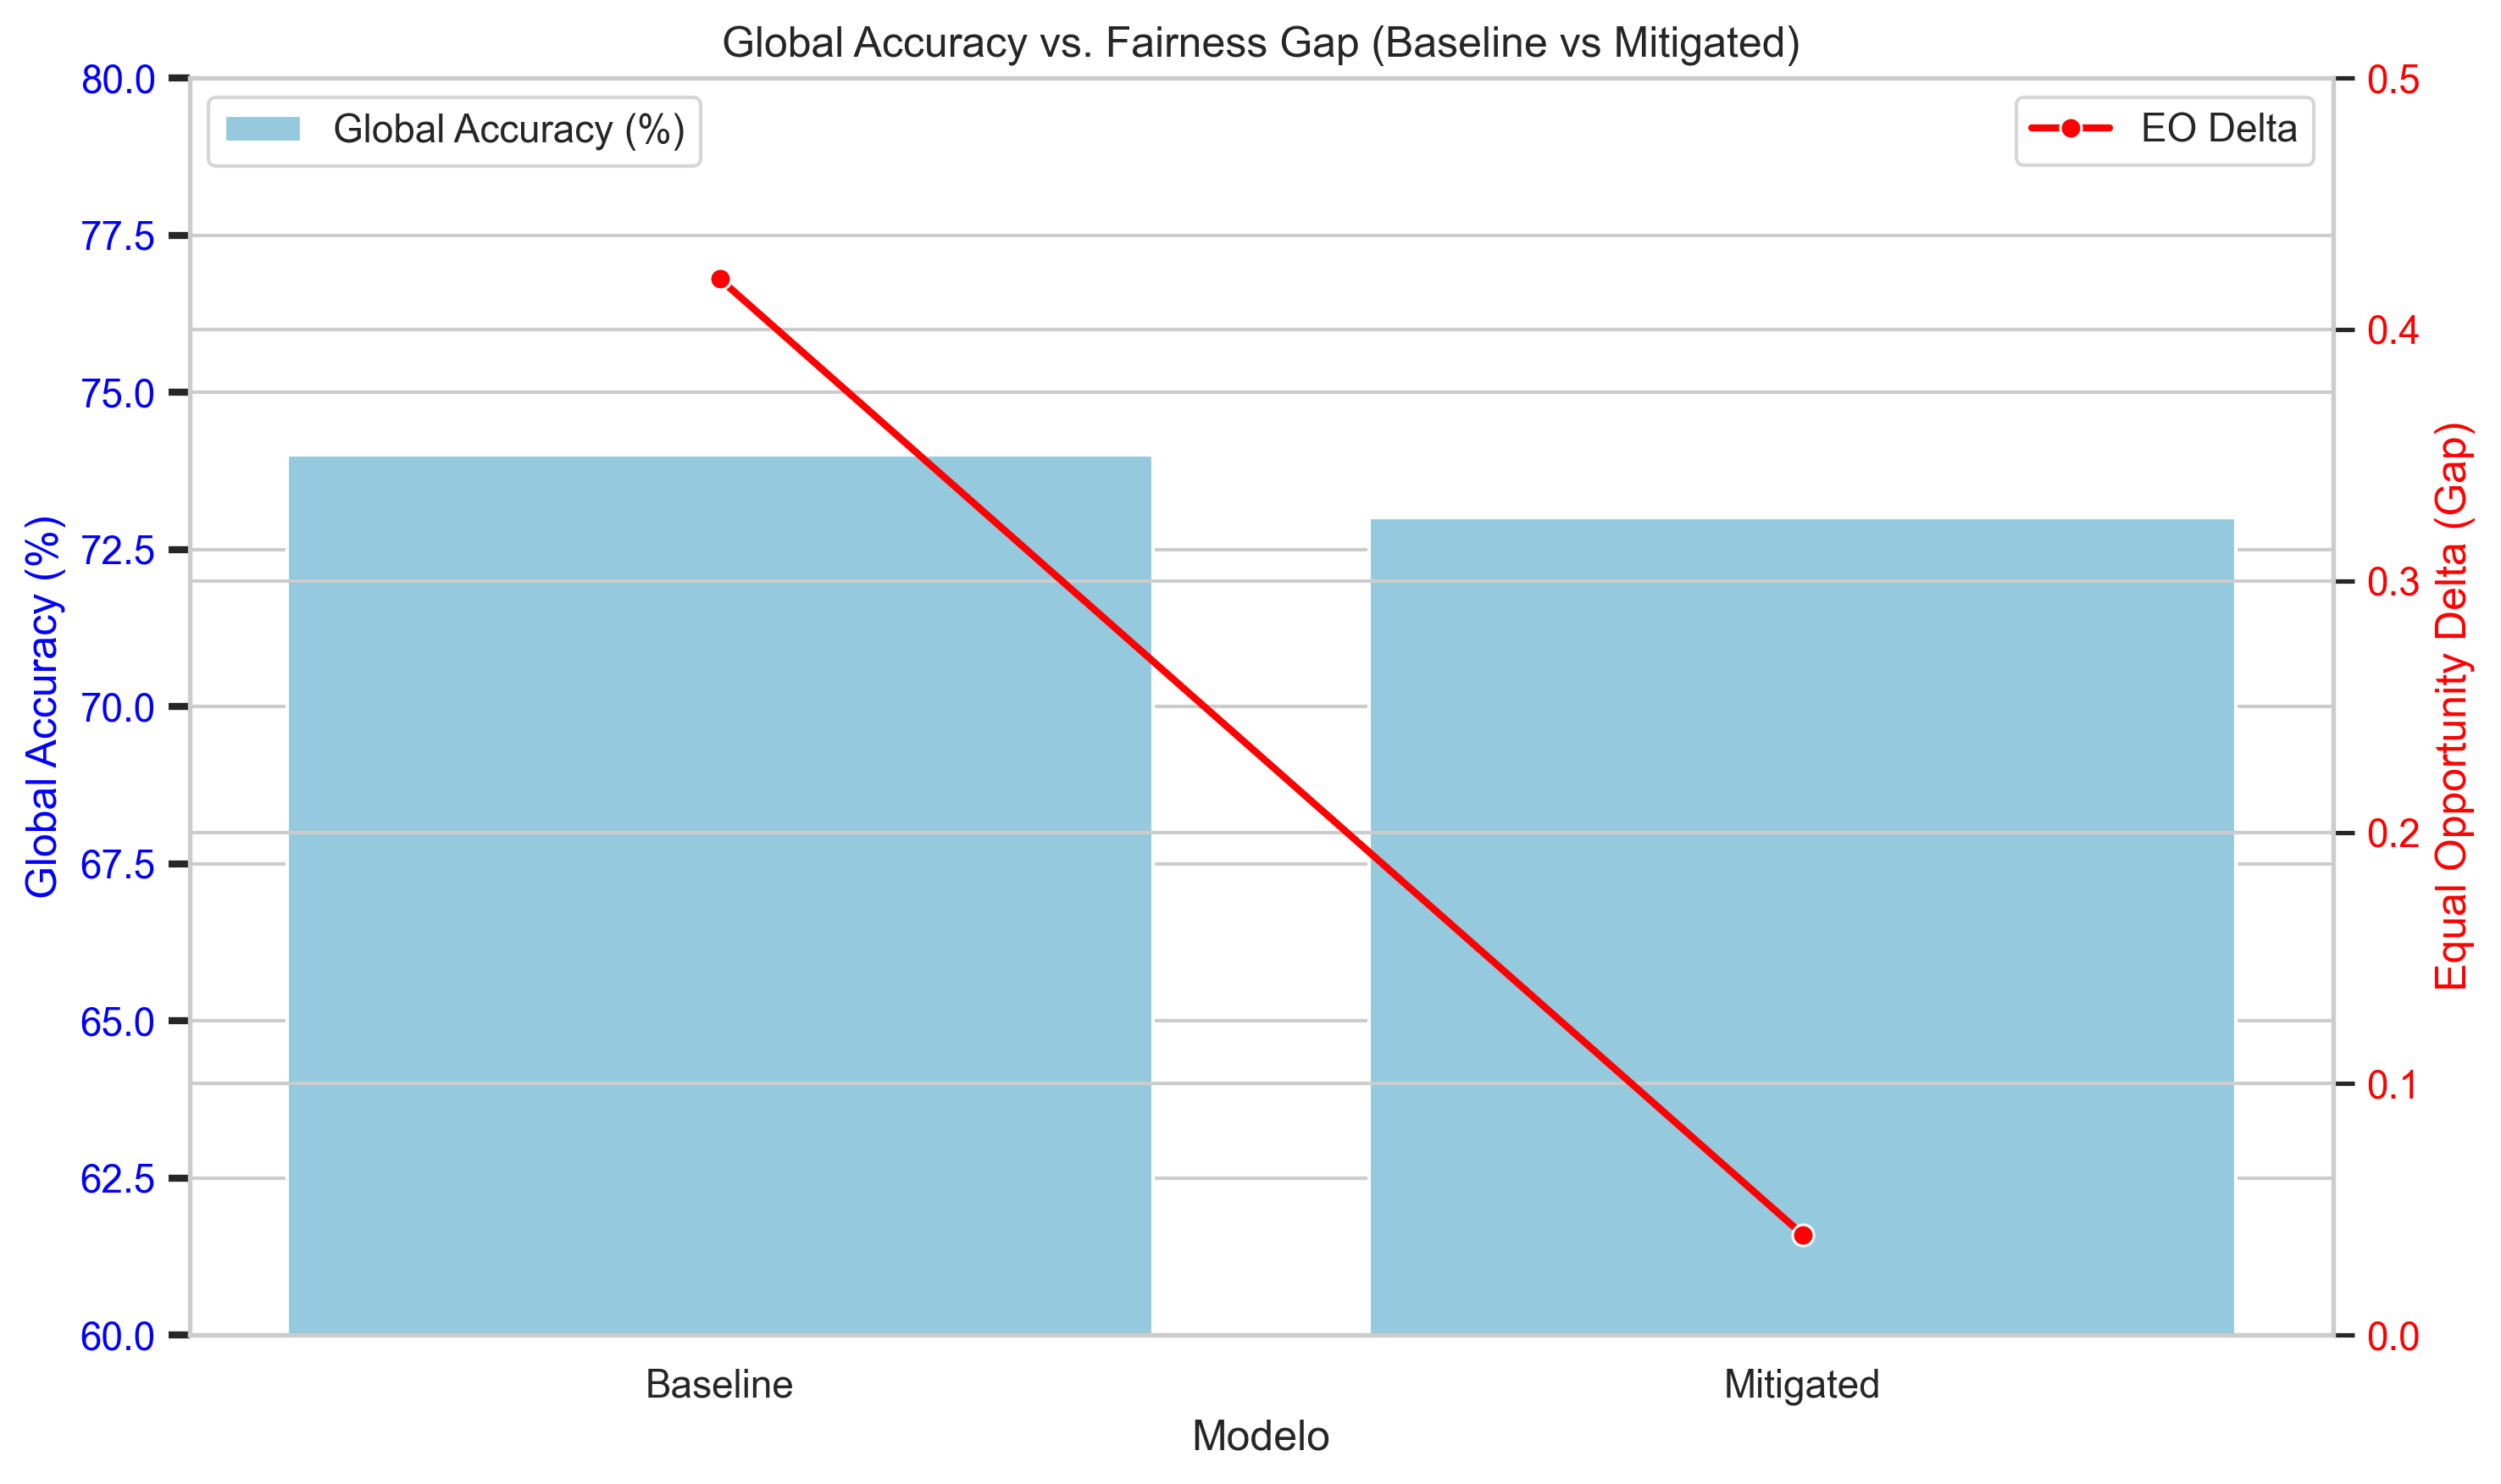

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_figure_3():
    """
    Gera o gráfico de Trade-off entre Acurácia e Equidade.
    Você precisa preencher os valores abaixo com os resultados do seu notebook!
    """
    
    # 1. COPIE AQUI OS VALORES QUE VOCÊ OBTEVE NA SUA AVALIAÇÃO:
    baseline_acc = 74.0  # Substitua pelo seu valor de acurácia baseline
    mitigated_acc = 73.0 # Substitua pelo seu valor de acurácia após mitigação
    
    baseline_eo = 0.42   # Substitua pelo seu Delta de Equal Opportunity baseline
    mitigated_eo = 0.04  # Substitua pelo seu Delta de Equal Opportunity mitigado
    
    # Criando o dataframe para o gráfico
    data = {
        'Modelo': ['Baseline', 'Mitigated'],
        'Accuracy': [baseline_acc, mitigated_acc],
        'Eq_Opportunity_Delta': [baseline_eo, mitigated_eo]
    }
    df_acc = pd.DataFrame(data)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Gráfico de barras para acurácia
    sns.barplot(data=df_acc, x='Modelo', y='Accuracy', ax=ax1, color='skyblue', label='Global Accuracy (%)')
    ax1.set_ylim(60, 80)
    ax1.set_ylabel('Global Accuracy (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue', width=2)
    
    ax2 = ax1.twinx()
    sns.lineplot(data=df_acc, x='Modelo', y='Eq_Opportunity_Delta', ax=ax2, marker='o', color='red', label='EO Delta', linewidth=2)
    ax2.set_ylabel('Equal Opportunity Delta (Gap)', color='red')
    ax2.set_ylim(0, 0.5)
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.title('Global Accuracy vs. Fairness Gap (Baseline vs Mitigated)')
    plt.tight_layout()
    plt.savefig('figura3.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Basta rodar a função abaixo:
plot_figure_3()

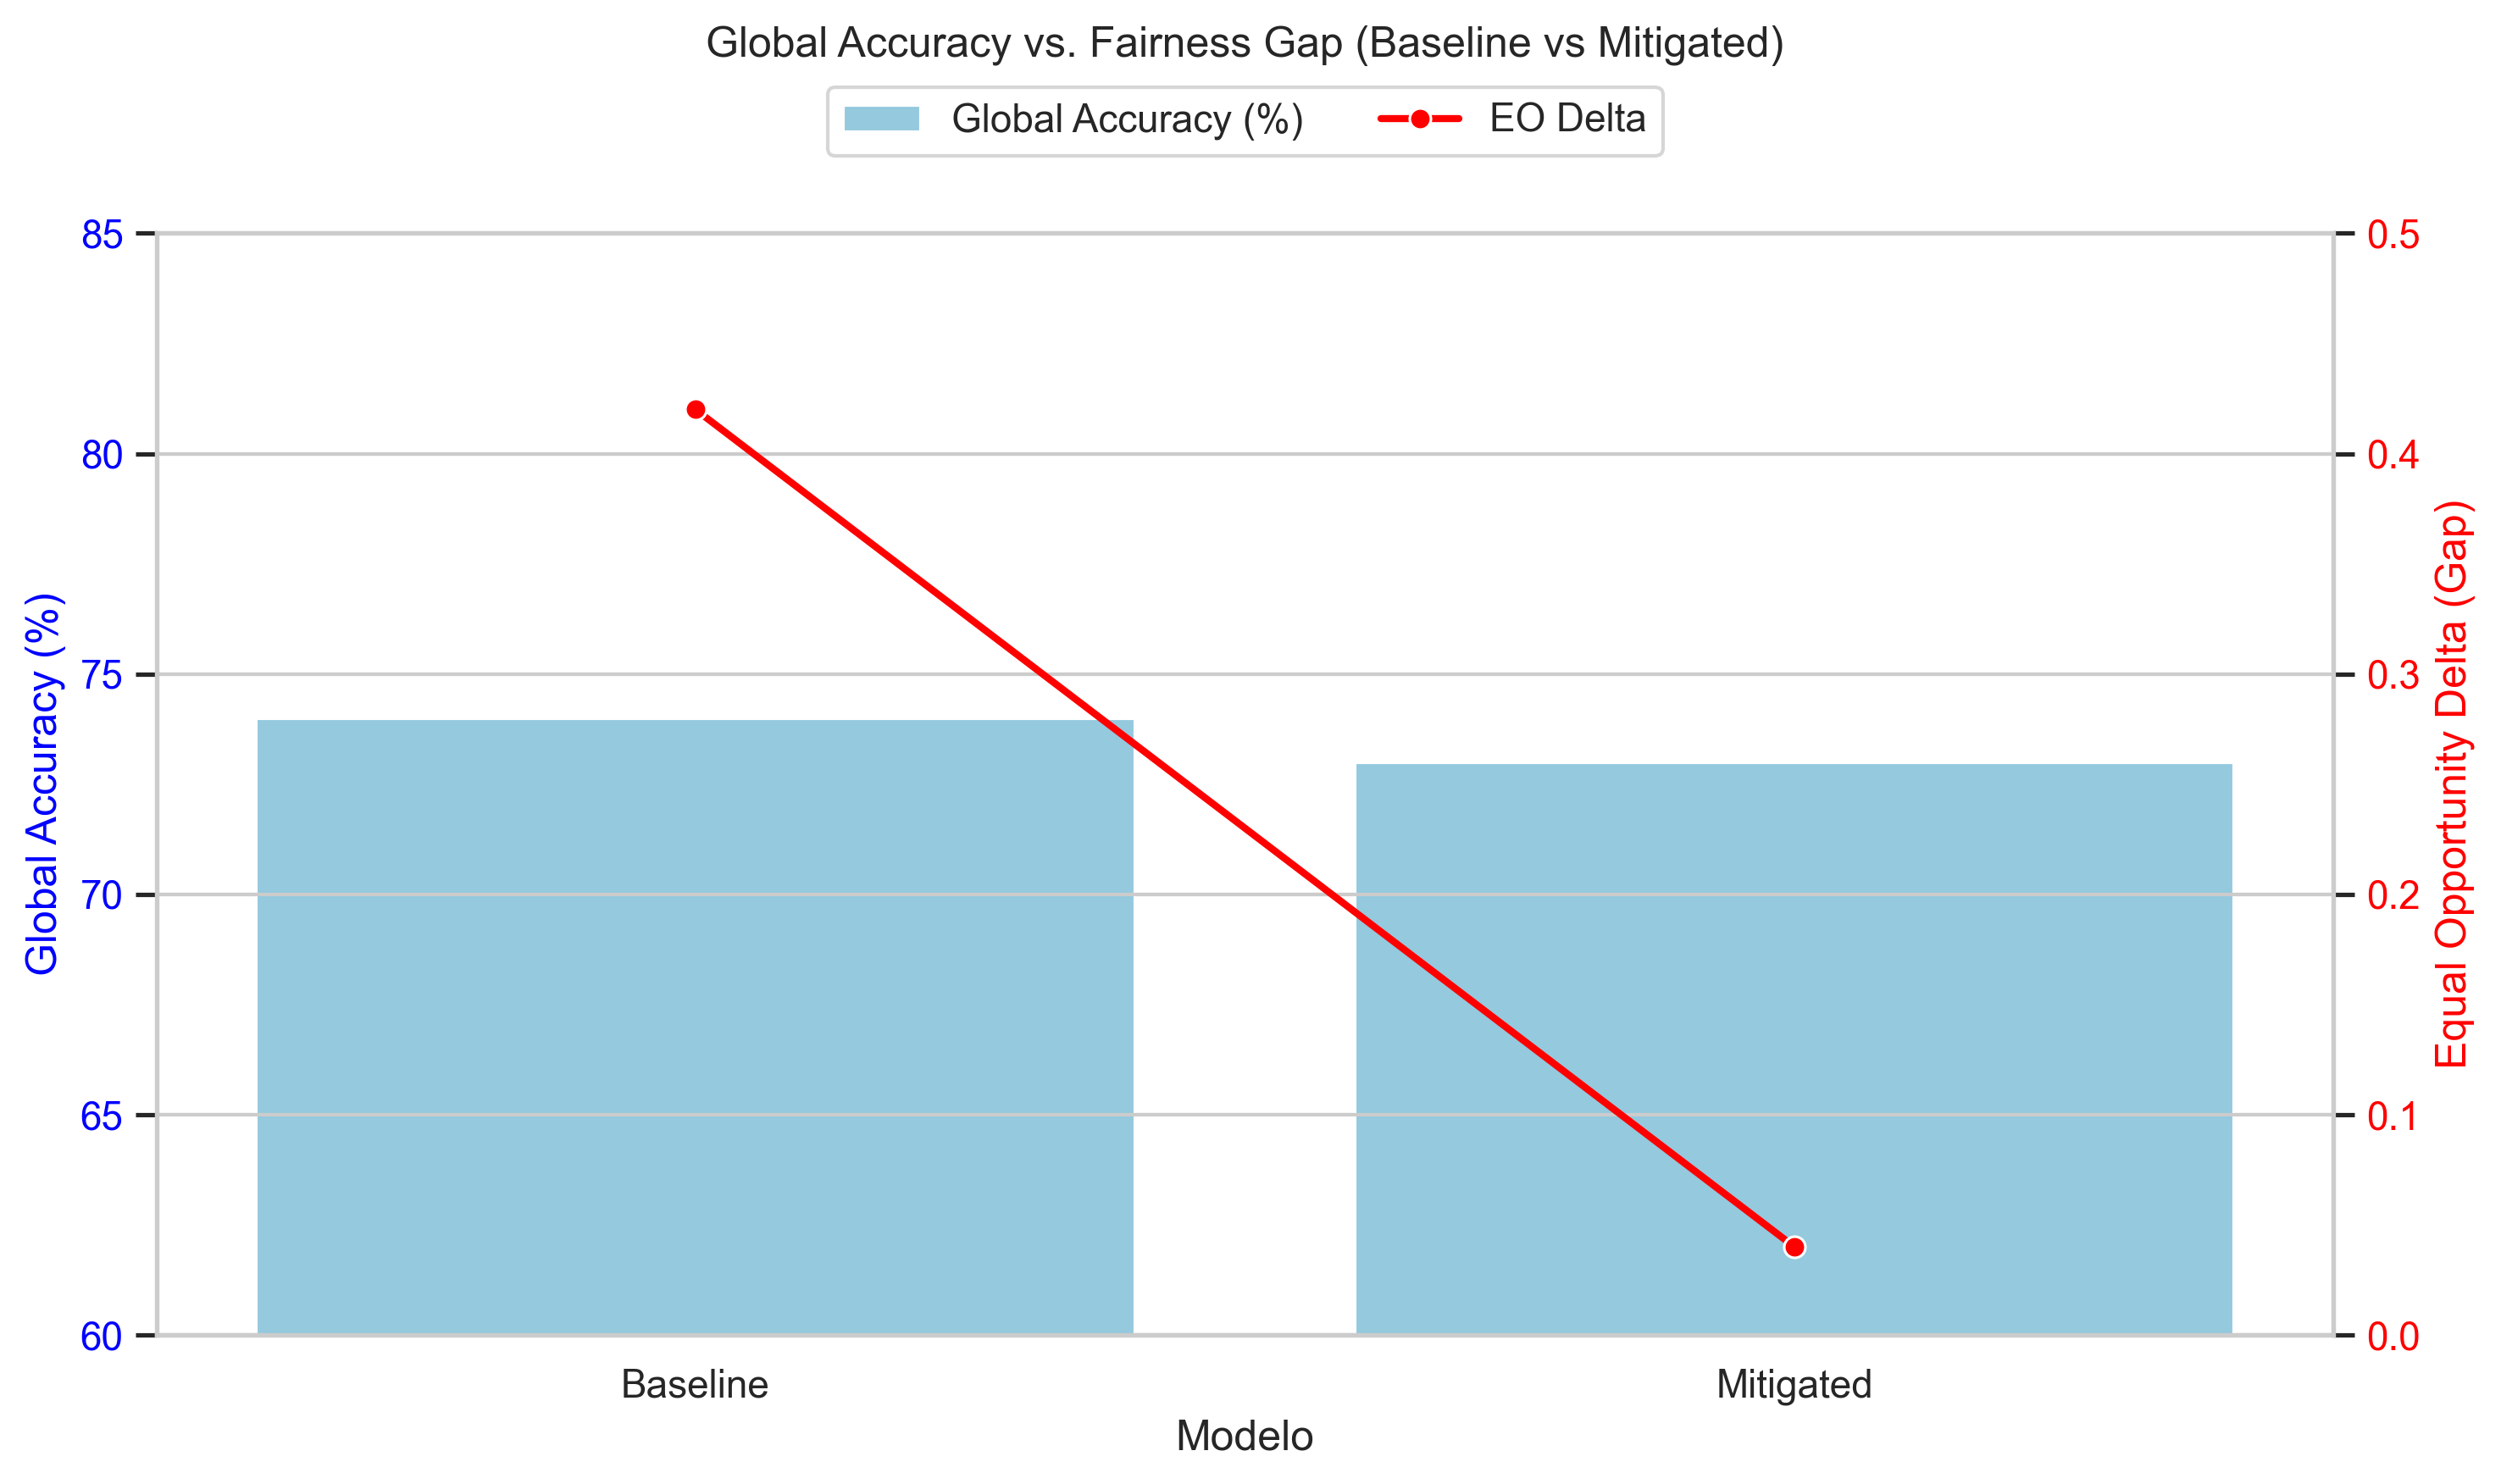

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_figure_3():
    """
    Gera o gráfico de Trade-off entre Acurácia e Equidade.
    As barras e as legendas estão ajustadas para evitar sobreposição.
    """
    
    # 1. COPIE AQUI OS VALORES QUE VOCÊ OBTEVE NA SUA AVALIAÇÃO:
    baseline_acc = 74.0  # Substitua pelo seu valor de acurácia baseline
    mitigated_acc = 73.0 # Substitua pelo seu valor de acurácia após mitigação
    
    baseline_eo = 0.42   # Substitua pelo seu Delta de Equal Opportunity baseline
    mitigated_eo = 0.04  # Substitua pelo seu Delta de Equal Opportunity mitigado
    
    # Criando o dataframe para o gráfico
    data = {
        'Modelo': ['Baseline', 'Mitigated'],
        'Accuracy': [baseline_acc, mitigated_acc],
        'Eq_Opportunity_Delta': [baseline_eo, mitigated_eo]
    }
    df_acc = pd.DataFrame(data)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # --- ALTERAÇÃO 1: Adicionado width=0.4 para afinar as barras ---
    sns.barplot(data=df_acc, x='Modelo', y='Accuracy', ax=ax1, color='skyblue', label='Global Accuracy (%)')
    
    # --- ALTERAÇÃO 2: Limite aumentado para 85 para não esmagar o gráfico ---
    ax1.set_ylim(60, 85)
    ax1.set_ylabel('Global Accuracy (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    sns.lineplot(data=df_acc, x='Modelo', y='Eq_Opportunity_Delta', ax=ax2, marker='o', color='red', label='EO Delta', linewidth=2)
    ax2.set_ylabel('Equal Opportunity Delta (Gap)', color='red')
    ax2.set_ylim(0, 0.5)
    ax2.tick_params(axis='y', labelcolor='red')
    
    # --- ALTERAÇÃO 3: Código que junta e organiza as legendas no topo ---
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(handles1 + handles2, labels1 + labels2, 
               loc='upper center', bbox_to_anchor=(0.5, 1.15), 
               ncol=2, frameon=True)
    
    if ax2.get_legend():
        ax2.get_legend().remove()
    # ------------------------------------------------------------------
    
    # O 'pad' afasta o título da legenda para ficar visualmente limpo
    plt.title('Global Accuracy vs. Fairness Gap (Baseline vs Mitigated)', pad=50)
    
    plt.tight_layout()
    plt.savefig('figure3.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Basta rodar a função abaixo:
plot_figure_3()

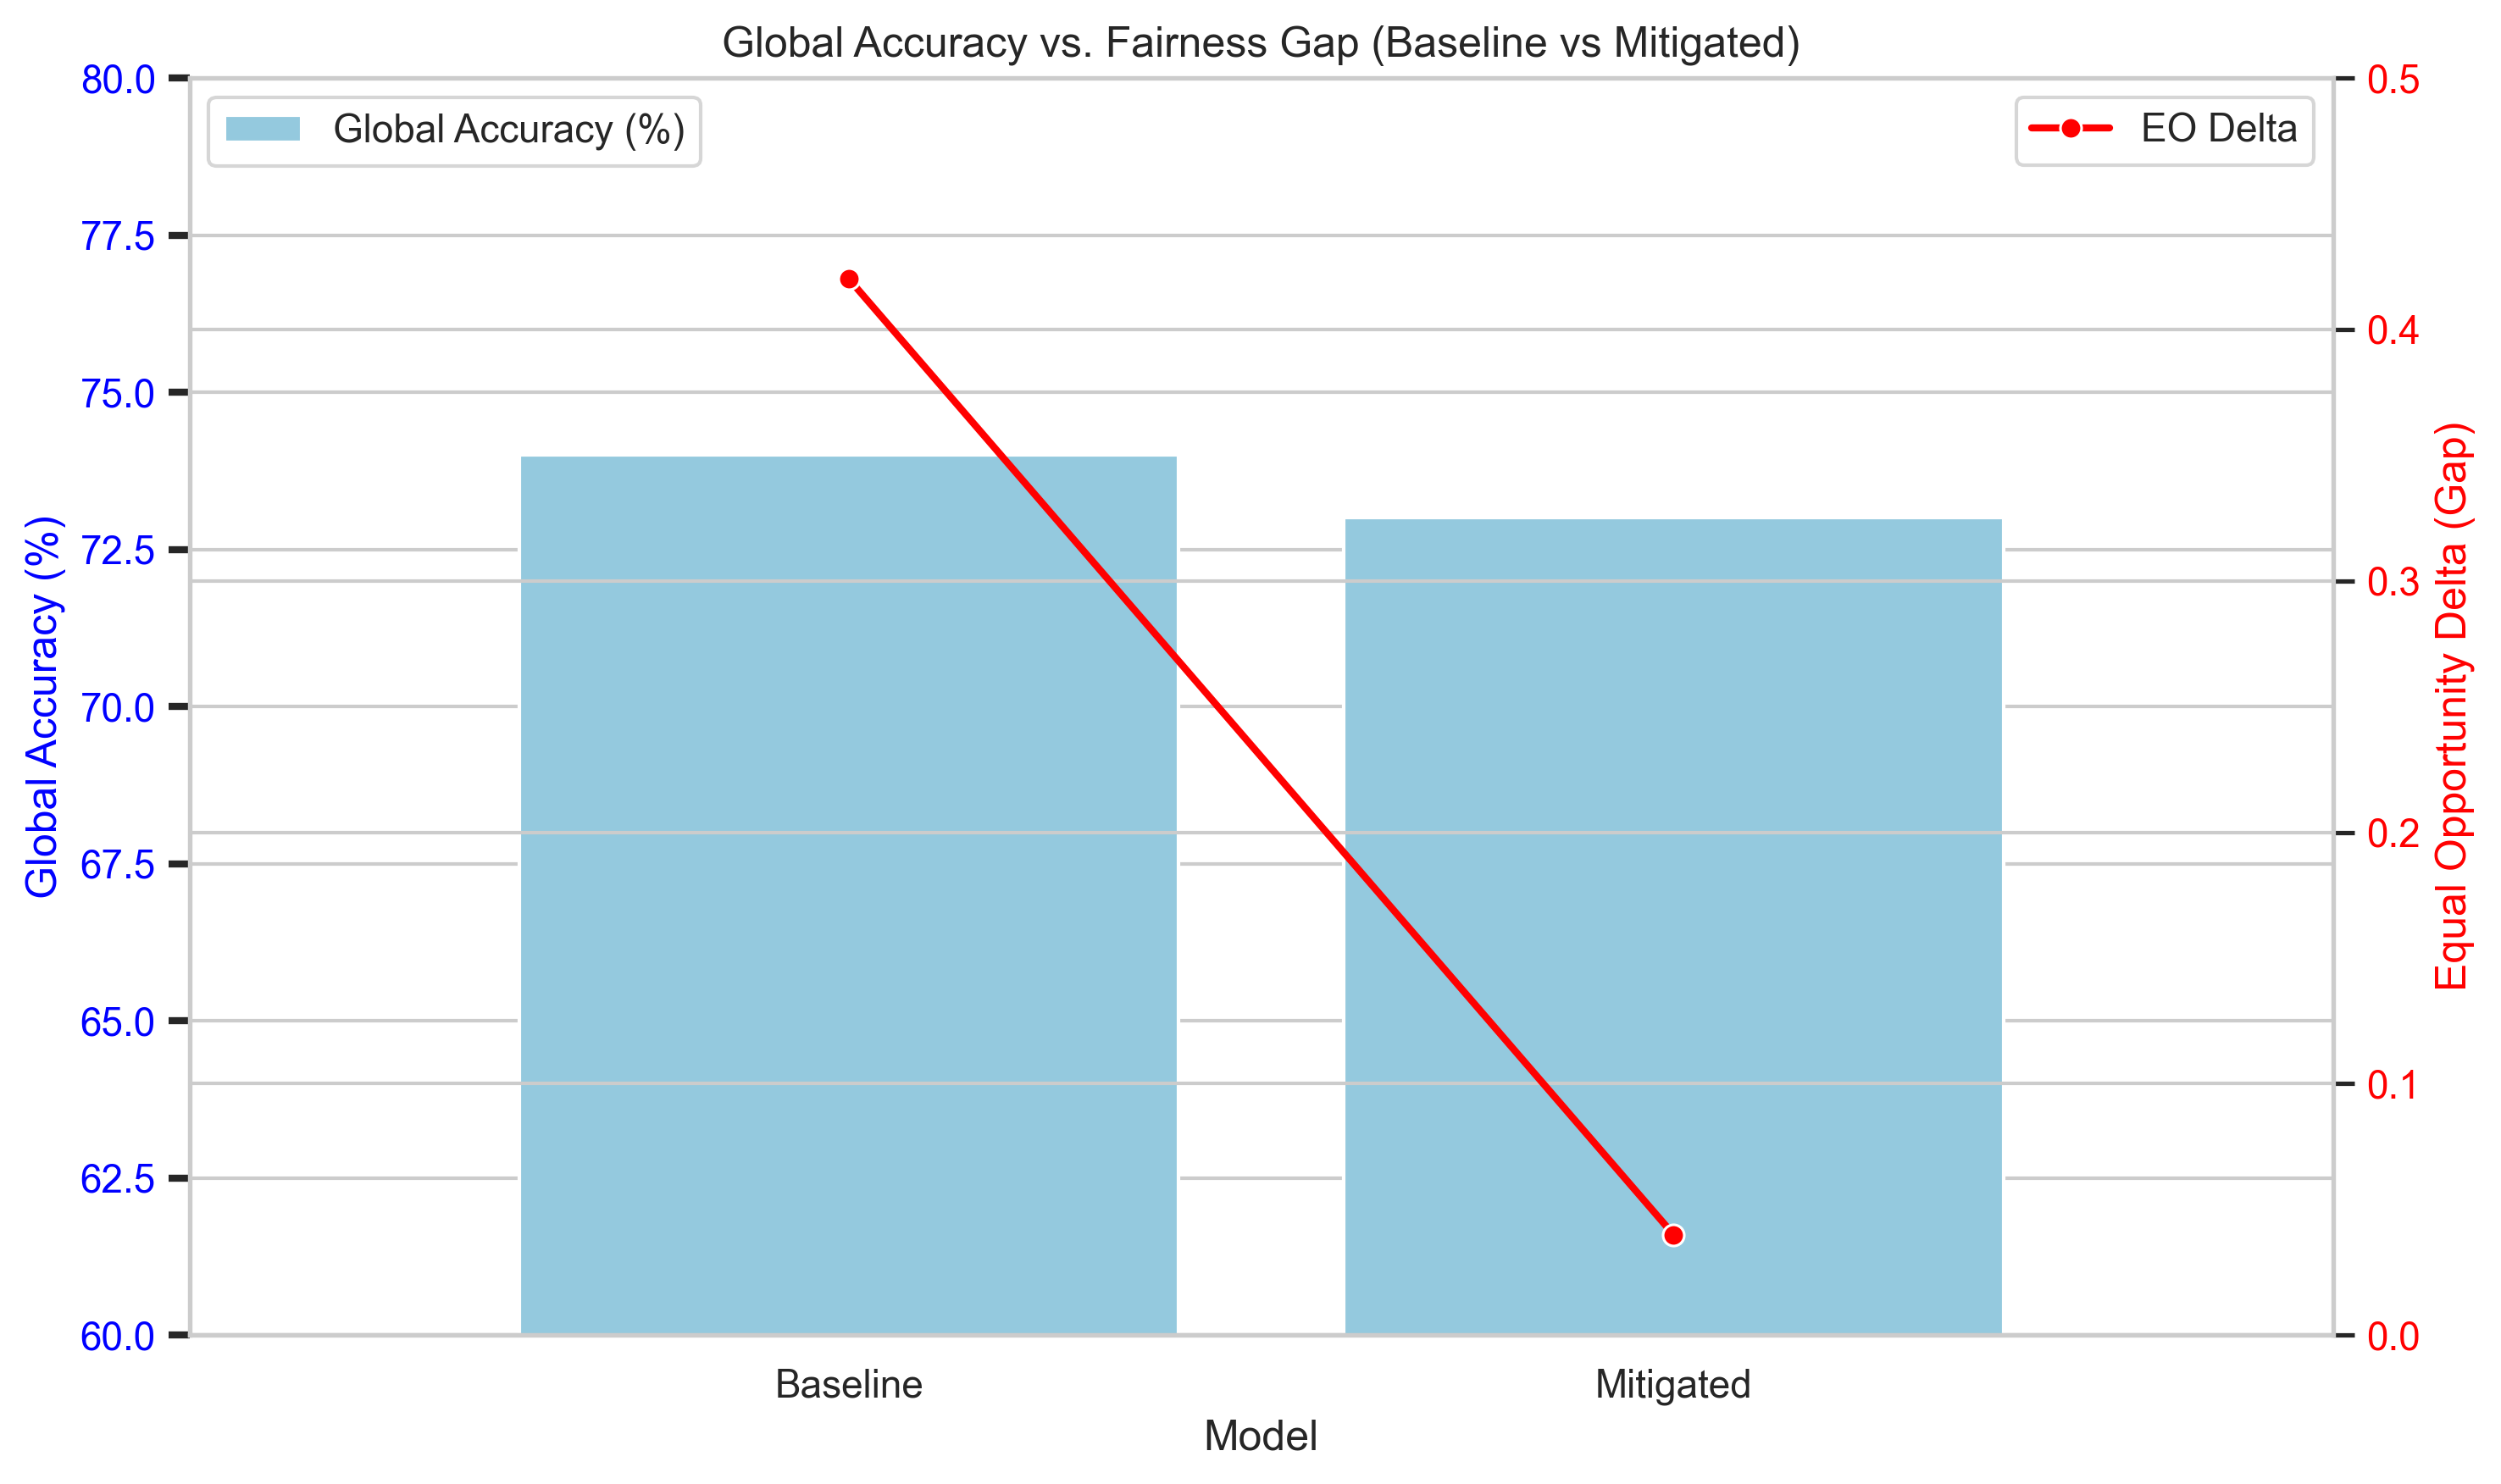

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_figure_3():
    """
    Gera o gráfico de Trade-off entre Acurácia e Equidade.
    Você precisa preencher os valores abaixo com os resultados do seu notebook!
    """
    
    # 1. COPIE AQUI OS VALORES QUE VOCÊ OBTEVE NA SUA AVALIAÇÃO:
    baseline_acc = 74.0  # Substitua pelo seu valor de acurácia baseline
    mitigated_acc = 73.0 # Substitua pelo seu valor de acurácia após mitigação
    
    baseline_eo = 0.42   # Substitua pelo seu Delta de Equal Opportunity baseline
    mitigated_eo = 0.04  # Substitua pelo seu Delta de Equal Opportunity mitigado
    
    # Criando o dataframe para o gráfico
    data = {
        'Model': ['Baseline', 'Mitigated'], # <-- ALTERADO AQUI
        'Accuracy': [baseline_acc, mitigated_acc],
        'Eq_Opportunity_Delta': [baseline_eo, mitigated_eo]
    }
    df_acc = pd.DataFrame(data)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Gráfico de barras para acurácia
    sns.barplot(data=df_acc, x='Model', y='Accuracy', ax=ax1, color='skyblue', label='Global Accuracy (%)') # <-- ALTERADO AQUI
    ax1.set_ylim(60, 80)
    ax1.set_xlim(-0.8, 1.8) # Afinar as barras
    ax1.set_ylabel('Global Accuracy (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue', width=2)
    
    ax2 = ax1.twinx()
    sns.lineplot(data=df_acc, x='Model', y='Eq_Opportunity_Delta', ax=ax2, marker='o', color='red', label='EO Delta', linewidth=2)
    ax2.set_ylabel('Equal Opportunity Delta (Gap)', color='red')
    ax2.set_ylim(0, 0.5)
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.title('Global Accuracy vs. Fairness Gap (Baseline vs Mitigated)')
    plt.tight_layout()
    plt.savefig('figura3_final.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Basta rodar a função abaixo:
plot_figure_3()